All data is pulled using the Coindesk API. A total of around 16 months of data is used, ending on 2026/03/01. The data will be used to train and test in a walk-forward approach in the strategy notebook.

In [ ]:
# Data handling
import requests
import pandas as pd
import numpy as np
import datetime

# Plotting
import matplotlib.pyplot as plt
import warnings

In [7]:
import json

with open('config.json', 'r') as f:
    config = json.load(f)

API_KEY = config['api_key']


# BTC-USD - Binance

In [ ]:
import time

# Target: 5 years of hourly data = 365 * 24 * 5 = 43,800 records
# API limit is 2000, so we need multiple calls (43,800 / 2000 = ~22 calls)
# Each call fetches up to 2000 records, moving backwards in time

LIMIT = 2000
TOTAL_HOURS = 12000
END_TIMESTAMP = 1772352000  # Starting point (most recent)

all_data = []
current_to_ts = END_TIMESTAMP
records_fetched = 0

while records_fetched < TOTAL_HOURS:
    response = requests.get(
        'https://data-api.coindesk.com/spot/v1/historical/hours',
        params={
            "market": "binance",
            "instrument": "BTC-USD",
            "aggregate": 1,
            "fill": "true",
            "apply_mapping": "false",
            "to_ts": current_to_ts,
            "limit": LIMIT,
            "api_key": API_KEY
        },
        headers={"Content-type": "application/json; charset=UTF-8"}
    )
    
    json_response = response.json()

    batch_df = pd.DataFrame(json_response['Data'])
    all_data.append(batch_df)
    
    batch_size = len(batch_df)
    records_fetched += batch_size
    
    # Get the earliest timestamp from this batch to use as next to_ts
    # Subtract 1 hour (3600 seconds) to avoid duplicate records
    current_to_ts = batch_df['TIMESTAMP'].min() - 60
    
    print(f"Fetched {batch_size} records. Total: {records_fetched}/{TOTAL_HOURS}. Next to_ts: {current_to_ts}")
    
    # Small delay to avoid rate limiting
    time.sleep(0.2)

# Combine all batches into single DataFrame
df = pd.concat(all_data, ignore_index=True)

# Remove any duplicates based on TIMESTAMP
df = df.drop_duplicates(subset=['TIMESTAMP'])

# Sort by timestamp ascending (oldest first)
df = df.sort_values('TIMESTAMP').reset_index(drop=True)

print(f"\nTotal records fetched: {len(df)}")
print(f"Date range: {pd.to_datetime(df['TIMESTAMP'].min(), unit='s')} to {pd.to_datetime(df['TIMESTAMP'].max(), unit='s')}")
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df.head()

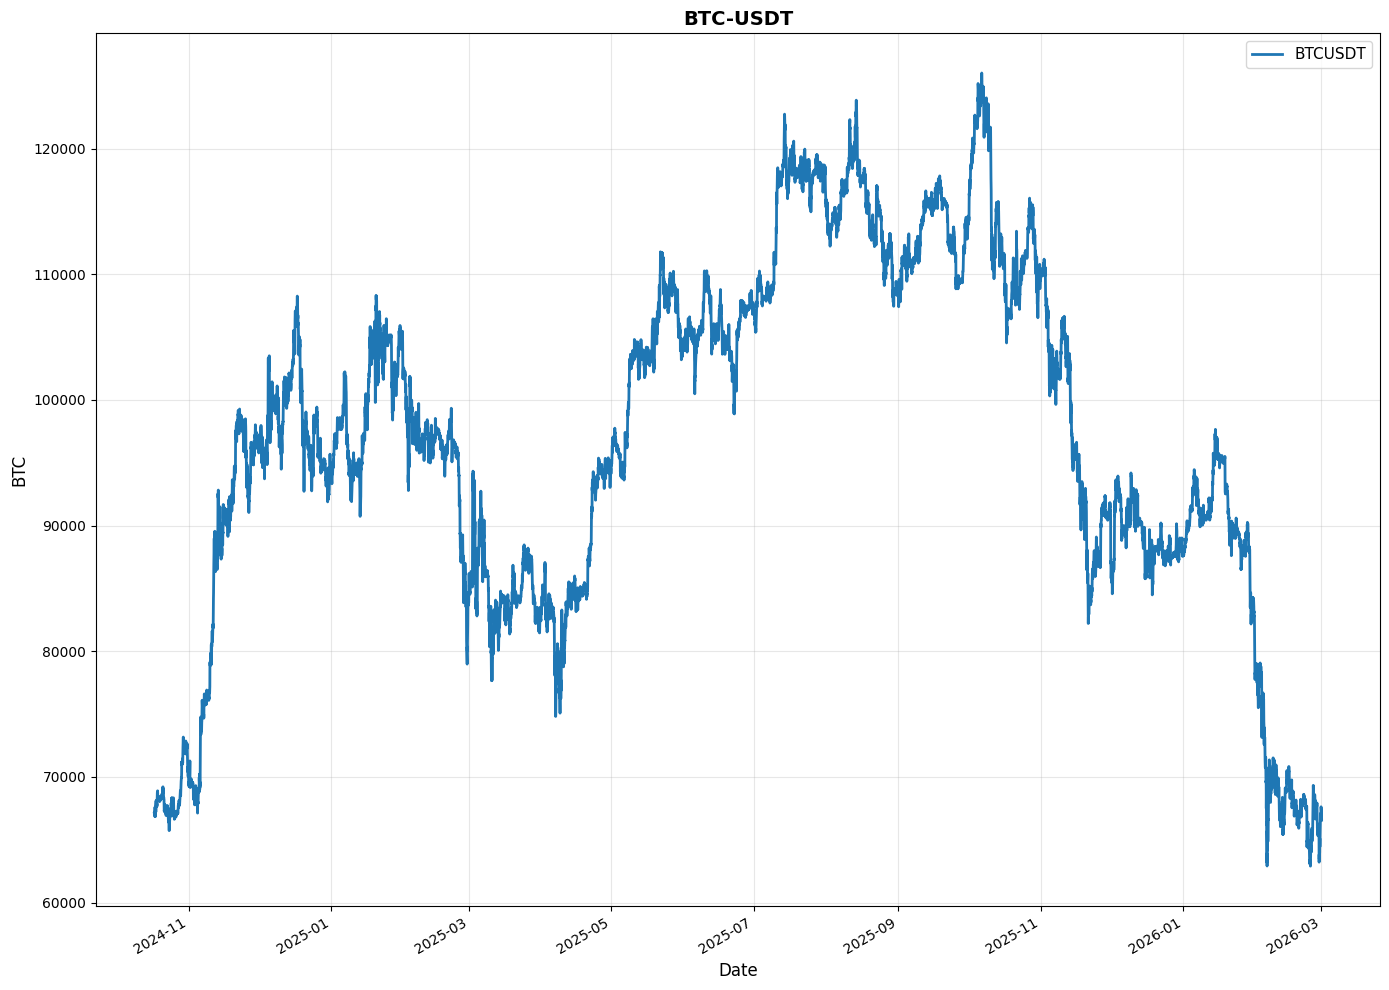

In [44]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.plot(df['TIMESTAMP'], df['CLOSE'], label='BTCUSDT', linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('BTC', fontsize=12)
ax.set_title('BTC-USDT', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Fix x-label crowding: set major formatter and locator
fig.autofmt_xdate(rotation=30)  # auto format with rotation for readability

plt.tight_layout()
plt.show()

In [46]:
df.to_csv('data/Price/btc-usdt-binance.csv', index=False)
df.shape

(12000, 29)

# BTC-USDT Perpetual Future

In [ ]:
import time

# Target: 5 years of hourly data = 365 * 24 * 5 = 43,800 records
# API limit is 2000, so we need multiple calls (43,800 / 2000 = ~22 calls)
# Each call fetches up to 2000 records, moving backwards in time

LIMIT = 2000
TOTAL_HOURS = 12000
END_TIMESTAMP = 1772352000  # Starting point (most recent)
MARKET = "binance"
INSTRUMENT = "BTC-USDT-VANILLA-PERPETUAL"

all_data = []
current_to_ts = END_TIMESTAMP
records_fetched = 0

while records_fetched < TOTAL_HOURS:
    response = requests.get(
        'https://data-api.coindesk.com/futures/v1/historical/hours',
        params={
            "market": MARKET,
            "instrument": INSTRUMENT,
            "aggregate": 1,
            "fill": "true",
            "apply_mapping": "false",
            "to_ts": current_to_ts,
            "limit": LIMIT,
            "api_key": API_KEY
        },
        headers={"Content-type": "application/json; charset=UTF-8"}
    )
    
    json_response = response.json()

    batch_df = pd.DataFrame(json_response['Data'])
    all_data.append(batch_df)
    
    batch_size = len(batch_df)
    records_fetched += batch_size
    
    # Get the earliest timestamp from this batch to use as next to_ts
    # Subtract 1 hour (3600 seconds) to avoid duplicate records
    current_to_ts = batch_df['TIMESTAMP'].min() - 60
    
    print(f"Fetched {batch_size} records. Total: {records_fetched}/{TOTAL_HOURS}. Next to_ts: {current_to_ts}")
    
    # Small delay to avoid rate limiting
    time.sleep(0.2)

# Combine all batches into single DataFrame
df = pd.concat(all_data, ignore_index=True)

# Remove any duplicates based on TIMESTAMP
df = df.drop_duplicates(subset=['TIMESTAMP'])

# Sort by timestamp ascending (oldest first)
df = df.sort_values('TIMESTAMP').reset_index(drop=True)

print(f"\nTotal records fetched: {len(df)}")
print(f"Date range: {pd.to_datetime(df['TIMESTAMP'].min(), unit='s')} to {pd.to_datetime(df['TIMESTAMP'].max(), unit='s')}")
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df.head()

Fetched 2000 records. Total: 2000/12000. Next to_ts: 1765155540
Fetched 2000 records. Total: 4000/12000. Next to_ts: 1757955540
Fetched 2000 records. Total: 6000/12000. Next to_ts: 1750755540
Fetched 2000 records. Total: 8000/12000. Next to_ts: 1743555540
Fetched 2000 records. Total: 10000/12000. Next to_ts: 1736355540
Fetched 2000 records. Total: 12000/12000. Next to_ts: 1729155540

Total records fetched: 12000
Date range: 2024-10-17 09:00:00 to 2026-03-01 08:00:00


,UNIT,TIMESTAMP,TYPE,MARKET,INSTRUMENT,OPEN,HIGH,LOW,CLOSE,FIRST_TRADE_TIMESTAMP,...,TOTAL_TRADES_UNKNOWN,NUMBER_OF_CONTRACTS,VOLUME,QUOTE_VOLUME,VOLUME_BUY,QUOTE_VOLUME_BUY,VOLUME_SELL,QUOTE_VOLUME_SELL,VOLUME_UNKNOWN,QUOTE_VOLUME_UNKNOWN
0,HOUR,2024-10-17 09:00:00,207,binance,BTCUSDT,67430.1,67516.7,67163.1,67174.8,1729155600,...,0,4766235,4766.235,3.209671e+08,1893.656,1.275483e+08,2872.579,1.934188e+08,0,0
1,HOUR,2024-10-17 10:00:00,207,binance,BTCUSDT,67174.8,67299.9,66766.0,67187.9,1729159200,...,0,14736965,14736.965,9.879200e+08,6957.199,4.664919e+08,7779.766,5.214281e+08,0,0
2,HOUR,2024-10-17 11:00:00,207,binance,BTCUSDT,67187.9,67271.9,66789.3,66853.6,1729162800,...,0,9380726,9380.726,6.279393e+08,4304.818,2.881464e+08,5075.908,3.397929e+08,0,0
3,HOUR,2024-10-17 12:00:00,207,binance,BTCUSDT,66853.6,67173.8,66790.8,67150.0,1729166400,...,0,8681412,8681.412,5.818517e+08,4599.453,3.082859e+08,4081.959,2.735657e+08,0,0
4,HOUR,2024-10-17 13:00:00,207,binance,BTCUSDT,67150.0,67338.6,66660.0,66993.9,1729170000,...,0,22472830,22472.830,1.505881e+09,10938.007,7.330725e+08,11534.823,7.728082e+08,0,0


In [5]:
df.keys()

Index(['UNIT', 'TIMESTAMP', 'TYPE', 'MARKET', 'INSTRUMENT', 'OPEN', 'HIGH',
       'LOW', 'CLOSE', 'FIRST_TRADE_TIMESTAMP', 'LAST_TRADE_TIMESTAMP',
       'FIRST_TRADE_PRICE', 'HIGH_TRADE_PRICE', 'HIGH_TRADE_TIMESTAMP',
       'LOW_TRADE_PRICE', 'LOW_TRADE_TIMESTAMP', 'LAST_TRADE_PRICE',
       'TOTAL_TRADES', 'TOTAL_TRADES_BUY', 'TOTAL_TRADES_SELL',
       'TOTAL_TRADES_UNKNOWN', 'NUMBER_OF_CONTRACTS', 'VOLUME', 'QUOTE_VOLUME',
       'VOLUME_BUY', 'QUOTE_VOLUME_BUY', 'VOLUME_SELL', 'QUOTE_VOLUME_SELL',
       'VOLUME_UNKNOWN', 'QUOTE_VOLUME_UNKNOWN'],
      dtype='object')

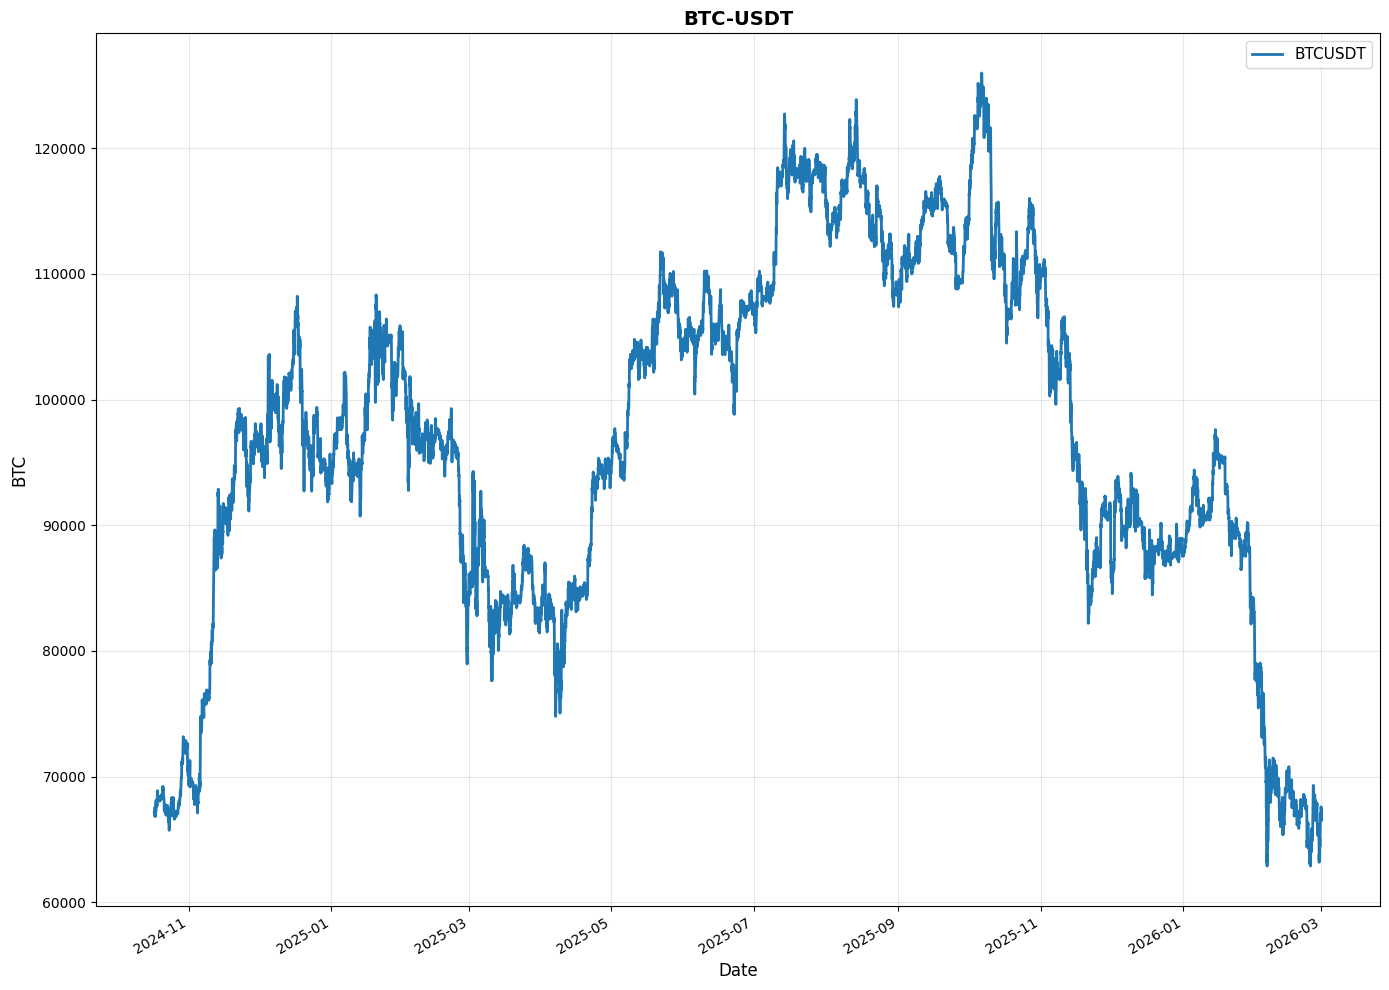

In [4]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.plot(df['TIMESTAMP'], df['CLOSE'], label='BTCUSDT', linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('BTC', fontsize=12)
ax.set_title('BTC-USDT', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Fix x-label crowding: set major formatter and locator
fig.autofmt_xdate(rotation=30)  # auto format with rotation for readability

plt.tight_layout()
plt.show()

In [6]:
df.to_csv('data/Price/btc-usdt-perp-binance.csv', index=False)
df.shape

(12000, 30)

## Funding Rate from dydxv4

In [ ]:
import time

# Target: 5 years of hourly data = 365 * 24 * 5 = 43,800 records
# API limit is 2000, so we need multiple calls (43,800 / 2000 = ~22 calls)
# Each call fetches up to 2000 records, moving backwards in time

LIMIT = 2000
TOTAL_HOURS = 12000
END_TIMESTAMP = 1772352000  # Starting point (most recent)
MARKET = "dydxv4"
INSTRUMENT = "BTC-USD"

all_data = []
current_to_ts = END_TIMESTAMP
records_fetched = 0

while records_fetched < TOTAL_HOURS:
    response = requests.get(
        'https://data-api.coindesk.com/futures/v1/historical/funding-rate/hours',
        params={
            "market": MARKET,
            "instrument": INSTRUMENT,
            "aggregate": 1,
            "fill": "true",
            "apply_mapping": "false",
            "to_ts": current_to_ts,
            "limit": LIMIT,
            "api_key": API_KEY
        },
        headers={"Content-type": "application/json; charset=UTF-8"}
    )
    
    json_response = response.json()

    batch_df = pd.DataFrame(json_response['Data'])
    all_data.append(batch_df)
    
    batch_size = len(batch_df)
    records_fetched += batch_size
    
    # Get the earliest timestamp from this batch to use as next to_ts
    # Subtract 1 hour (3600 seconds) to avoid duplicate records
    current_to_ts = batch_df['TIMESTAMP'].min() - 60
    
    print(f"Fetched {batch_size} records. Total: {records_fetched}/{TOTAL_HOURS}. Next to_ts: {current_to_ts}")
    
    # Small delay to avoid rate limiting
    time.sleep(0.2)

# Combine all batches into single DataFrame
df = pd.concat(all_data, ignore_index=True)

# Remove any duplicates based on TIMESTAMP
df = df.drop_duplicates(subset=['TIMESTAMP'])

# Sort by timestamp ascending (oldest first)
df = df.sort_values('TIMESTAMP').reset_index(drop=True)

print(f"\nTotal records fetched: {len(df)}")
print(f"Date range: {pd.to_datetime(df['TIMESTAMP'].min(), unit='s')} to {pd.to_datetime(df['TIMESTAMP'].max(), unit='s')}")
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df.head()

Fetched 2000 records. Total: 2000/12000. Next to_ts: 1765155540
Fetched 2000 records. Total: 4000/12000. Next to_ts: 1757955540
Fetched 2000 records. Total: 6000/12000. Next to_ts: 1750755540
Fetched 2000 records. Total: 8000/12000. Next to_ts: 1743555540
Fetched 2000 records. Total: 10000/12000. Next to_ts: 1736355540
Fetched 2000 records. Total: 12000/12000. Next to_ts: 1729155540

Total records fetched: 12000
Date range: 2024-10-17 09:00:00 to 2026-03-01 08:00:00


,UNIT,TIMESTAMP,TYPE,MARKET,INSTRUMENT,INTERVAL_MS,OPEN,HIGH,LOW,CLOSE,FIRST_MESSAGE_TIMESTAMP,LAST_MESSAGE_TIMESTAMP,FIRST_MESSAGE_VALUE,HIGH_MESSAGE_VALUE,HIGH_MESSAGE_TIMESTAMP,LOW_MESSAGE_VALUE,LOW_MESSAGE_TIMESTAMP,LAST_MESSAGE_VALUE,TOTAL_FUNDING_RATE_UPDATES
0,HOUR,2024-10-17 09:00:00,227,dydxv4,BTC-USD,3600000,0.000006,0.000006,-0.000005,-0.000005,1.729156e+09,1.729156e+09,-0.000005,-0.000005,1.729156e+09,-0.000005,1.729156e+09,-0.000005,1
1,HOUR,2024-10-17 10:00:00,227,dydxv4,BTC-USD,3600000,-0.000005,0.000002,-0.000005,0.000002,1.729159e+09,1.729159e+09,0.000002,0.000002,1.729159e+09,0.000002,1.729159e+09,0.000002,1
2,HOUR,2024-10-17 11:00:00,227,dydxv4,BTC-USD,3600000,0.000002,0.000009,0.000002,0.000009,1.729163e+09,1.729163e+09,0.000009,0.000009,1.729163e+09,0.000009,1.729163e+09,0.000009,1
3,HOUR,2024-10-17 12:00:00,227,dydxv4,BTC-USD,3600000,0.000009,0.000019,0.000009,0.000019,1.729166e+09,1.729166e+09,0.000019,0.000019,1.729166e+09,0.000019,1.729166e+09,0.000019,1
4,HOUR,2024-10-17 13:00:00,227,dydxv4,BTC-USD,3600000,0.000019,0.000029,0.000019,0.000029,1.729170e+09,1.729170e+09,0.000029,0.000029,1.729170e+09,0.000029,1.729170e+09,0.000029,1


In [ ]:
df.to_csv('data/Funding Rate/btc-perp-fr.csv', index=False)
df.shape

(18000, 19)

In [47]:
df = pd.read_csv('data/Funding Rate/btc-perp-fr.csv')
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
df.shape

(12000, 19)

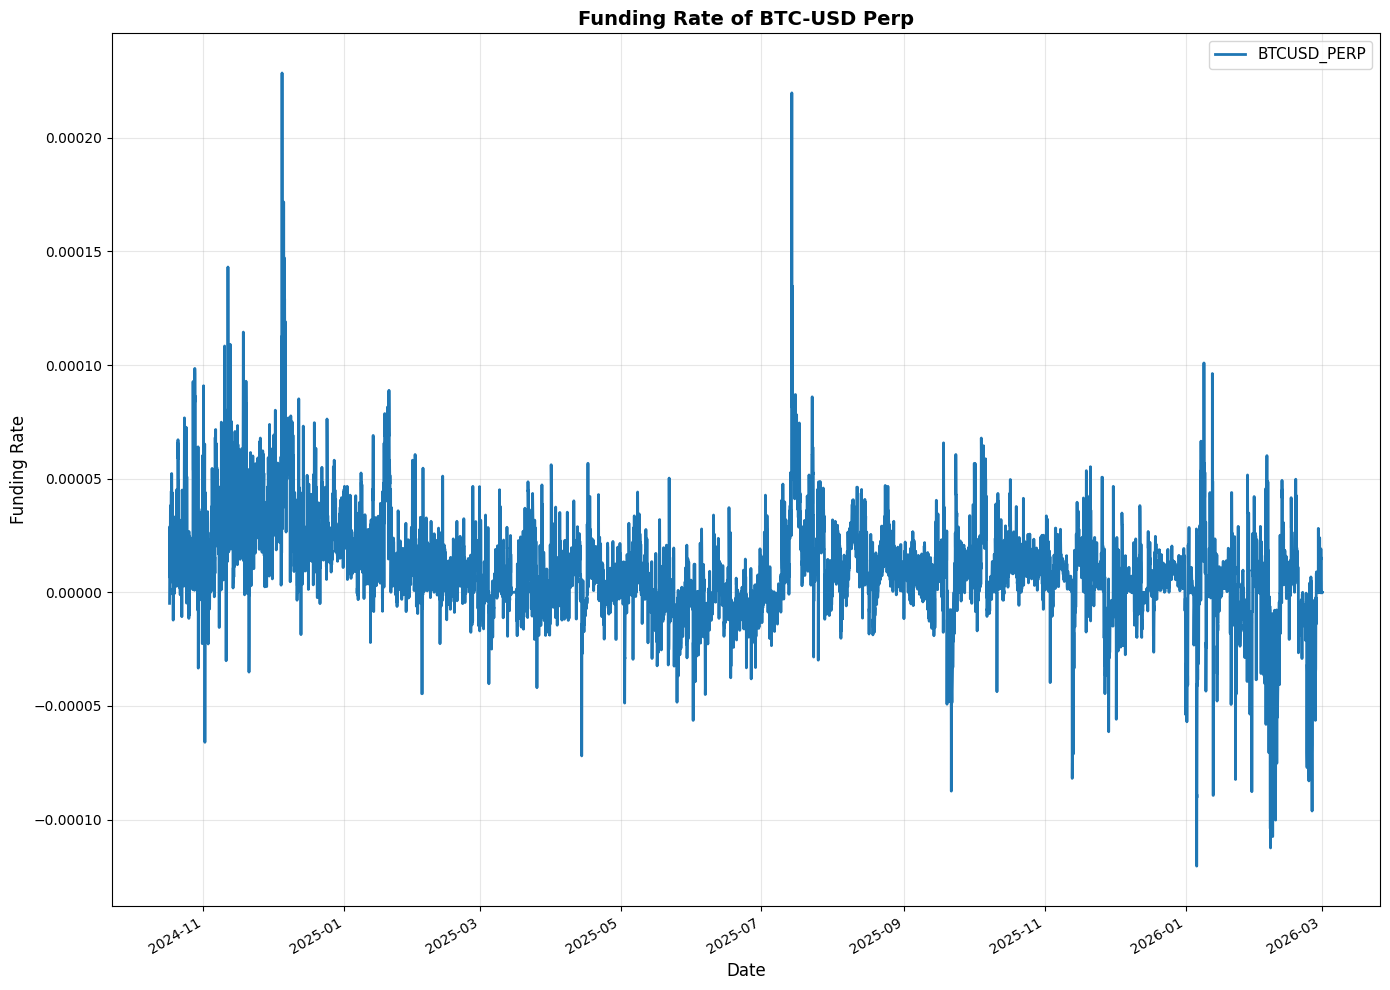

In [42]:
ohlc = df[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE']]

fig, ax = plt.subplots(figsize=(14, 10))
ax.plot(ohlc['TIMESTAMP'], ohlc['CLOSE'], label='BTCUSD_PERP', linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Funding Rate', fontsize=12)
ax.set_title('Funding Rate of BTC-USD Perp', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Fix x-label crowding: set major formatter and locator
fig.autofmt_xdate(rotation=30)  # auto format with rotation for readability

plt.tight_layout()
plt.show()

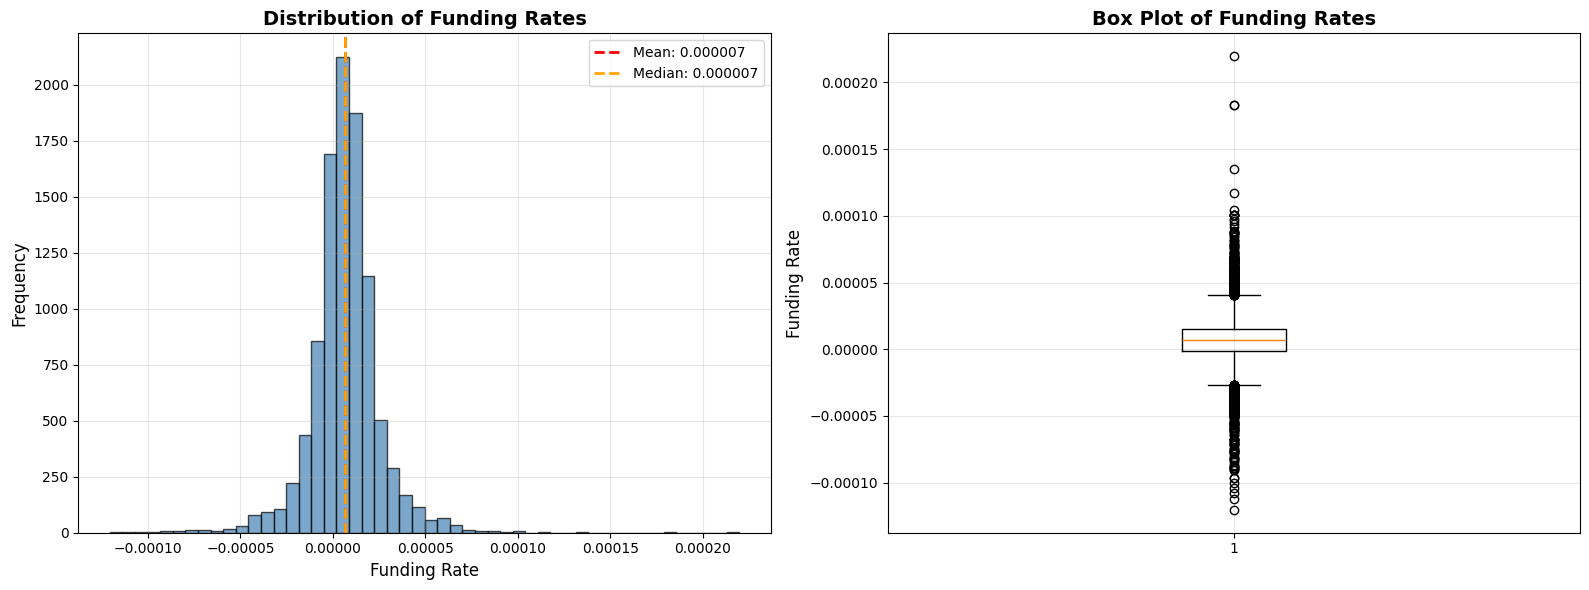

Summary Statistics:
count    10000.000000
mean         0.000007
std          0.000019
min         -0.000121
25%         -0.000002
50%          0.000007
75%          0.000015
max          0.000220
Name: CLOSE, dtype: float64


In [7]:
# Distribution of Funding Rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(ohlc['CLOSE'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(ohlc['CLOSE'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {ohlc['CLOSE'].mean():.6f}")
axes[0].axvline(ohlc['CLOSE'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {ohlc['CLOSE'].median():.6f}")
axes[0].set_xlabel('Funding Rate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Funding Rates', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(ohlc['CLOSE'], vert=True)
axes[1].set_ylabel('Funding Rate', fontsize=12)
axes[1].set_title('Box Plot of Funding Rates', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(ohlc['CLOSE'].describe())